Download complete!
Images shape: (106, 100, 100, 3)
Poses shape: (106, 4, 4)
Focal length: 138.88887889922103


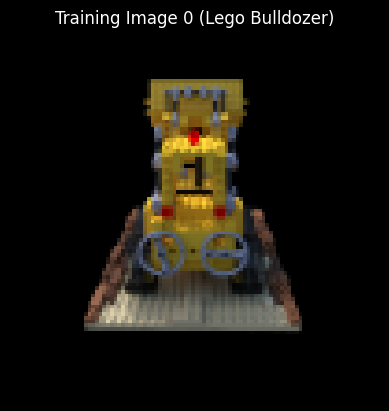

In [1]:
#1.DOWNLOAD AND LOAD THE DATASET
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. Download the Tiny NeRF dataset if we don't have it
url = "http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz"
filename = "tiny_nerf_data.npz"

if not os.path.exists(filename):
    print(f"Downloading {filename}...")
    response = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(response.content)
    print("Download complete!")

# 2. Load the data into memory
data = np.load(filename)
images = data['images'] # Shape: (106, 100, 100, 3) -> 106 images, 100x100 resolution, RGB
poses = data['poses']   # Shape: (106, 4, 4) -> 106 camera transformation matrices
focal = data['focal']   # Shape: () -> A single focal length value

print(f"Images shape: {images.shape}")
print(f"Poses shape: {poses.shape}")
print(f"Focal length: {focal}")

# 3. Let's look at the first image to make sure it loaded correctly
plt.imshow(images[0])
plt.title("Training Image 0 (Lego Bulldozer)")
plt.axis('off')
plt.show()



In [2]:
#The Ray Sampler (The Core Graphics Math)-Using PyTorch function to generate those rays:
def get_rays(H, W, focal, c2w):
    """
    Calculates the origin and direction of a ray for every pixel in the image.

    Args:
        H (int): Image height
        W (int): Image width
        focal (float): Focal length of the camera
        c2w (torch.Tensor): The 4x4 Camera-to-World matrix for this specific image

    Returns:
        rays_o (torch.Tensor): The origins of the rays (H, W, 3)
        rays_d (torch.Tensor): The directions of the rays (H, W, 3)
    """
    # 1. Create a grid of 2D pixel coordinates (x, y)
    i, j = torch.meshgrid(torch.arange(W, dtype=torch.float32),
                          torch.arange(H, dtype=torch.float32), indexing='xy')

    # 2. Map the 2D pixel coordinates to 3D Camera Space directions
    # We shift by half the image size (W/2, H/2) to center the optical axis
    dirs = torch.stack([(i - W * 0.5) / focal,
                        -(j - H * 0.5) / focal,
                        -torch.ones_like(i)], -1)

    # 3. Rotate the ray directions from Camera Space to World Space
    # c2w[:3, :3] is the rotation part of the matrix
    rays_d = torch.sum(dirs[..., np.newaxis, :] * c2w[:3, :3], -1)

    # 4. The origin of all rays is simply the camera's position in World Space
    # c2w[:3, -1] is the translation (x,y,z position) part of the matrix
    rays_o = c2w[:3, -1].expand(rays_d.shape)

    return rays_o, rays_d

# Test the function by converting our first numpy pose into a PyTorch tensor
H, W = images.shape[1:3]
test_c2w = torch.tensor(poses[0], dtype=torch.float32)
test_focal = torch.tensor(focal, dtype=torch.float32)

rays_o, rays_d = get_rays(H, W, test_focal, test_c2w)
print(f"Ray Origins shape: {rays_o.shape}")
print(f"Ray Directions shape: {rays_d.shape}")

Ray Origins shape: torch.Size([100, 100, 3])
Ray Directions shape: torch.Size([100, 100, 3])


In [3]:
#WRITING THE 3D SAMPLING FUNCTION
import torch

def sample_points_along_rays(rays_o, rays_d, near, far, N_samples, perturb=True):
    """
    Samples 3D points along rays using stratified sampling.

    Args:
        rays_o: Ray origins, shape (..., 3)
        rays_d: Ray directions, shape (..., 3)
        near: Near clipping bound for sampling (float)
        far: Far clipping bound for sampling (float)
        N_samples: Number of points to sample per ray (int)
        perturb: Whether to apply random jitter to the sample points (bool)

    Returns:
        pts: 3D coordinates of the sampled points, shape (..., N_samples, 3)
        z_vals: The t-values (depths) of the sampled points, shape (..., N_samples)
    """
    # 1. Create uniformly spaced t-values between the near and far planes
    t_vals = torch.linspace(near, far, N_samples, dtype=rays_o.dtype, device=rays_o.device)

    # Broadcast t_vals to match the batch dimensions of the rays
    # If rays_o is (H, W, 3), z_vals becomes (H, W, N_samples)
    batch_shape = list(rays_o.shape[:-1])
    z_vals = t_vals.view([1] * len(batch_shape) + [N_samples]).expand(batch_shape + [N_samples]).clone()

    # 2. Apply Stratified Sampling (Random Jitter) during training
    if perturb:
        # Calculate the midpoints between the uniform samples
        mids = 0.5 * (z_vals[..., 1:] + z_vals[..., :-1])
        upper = torch.cat([mids, z_vals[..., -1:]], -1)
        lower = torch.cat([z_vals[..., :1], mids], -1)

        # Generate random noise and distribute the points randomly within their bins
        t_rand = torch.rand(z_vals.shape, dtype=rays_o.dtype, device=rays_o.device)
        z_vals = lower + (upper - lower) * t_rand

    # 3. Calculate the 3D coordinate for each sampled point: r(t) = o + t*d
    # We add unsqueezed dimensions so the broadcasting math lines up correctly
    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]

    return pts, z_vals

# --- Let's test it with the rays we generated in the previous step ---
# For the Tiny NeRF Lego dataset, standard near and far bounds are 2.0 and 6.0
near_bound = 2.0
far_bound = 6.0
samples_per_ray = 64 # We will sample 64 points along each ray

# Using the rays_o and rays_d from our get_rays() test
pts, z_vals = sample_points_along_rays(rays_o, rays_d, near_bound, far_bound, samples_per_ray, perturb=True)

print(f"Sampled Points shape: {pts.shape}") # Expected: (100, 100, 64, 3)
print(f"Depth Values shape: {z_vals.shape}") # Expected: (100, 100, 64)

Sampled Points shape: torch.Size([100, 100, 64, 3])
Depth Values shape: torch.Size([100, 100, 64])


In [4]:
#STEP 5 WRITING THE PYTORCH CODE FOR THE MULTI-LAYER PERCEPTRON (MLP)
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------------------------------------
# 1. Positional Encoding
# -----------------------------------------------------------
def positional_encoding(tensor, num_frequencies):
    """
    Maps a low-dimensional input (like 3D coordinates) to a higher-dimensional space
    using sine and cosine functions of increasing frequencies.
    """
    encoding = [tensor]
    for i in range(num_frequencies):
        # We multiply by pi and increase the frequency by powers of 2
        for fn in [torch.sin, torch.cos]:
            encoding.append(fn(2.0 ** i * torch.pi * tensor))

    # Concatenate all the new frequency bands along the last dimension
    return torch.cat(encoding, dim=-1)


# -----------------------------------------------------------
# 2. The Tiny NeRF Multi-Layer Perceptron (MLP)
# -----------------------------------------------------------
class TinyNeRF(nn.Module):
    def __init__(self, pos_in_dims, dir_in_dims, filter_size=256):
        super().__init__()

        self.pos_in_dims = pos_in_dims

        # Phase 1: Processing the 3D Position
        # 8 Linear layers to process the spatial coordinates
        self.layer1 = nn.Linear(pos_in_dims, filter_size)
        self.layer2 = nn.Linear(filter_size, filter_size)
        self.layer3 = nn.Linear(filter_size, filter_size)
        self.layer4 = nn.Linear(filter_size, filter_size)

        # Skip Connection Layer (Adds the original input back in to prevent vanishing gradients)
        self.layer5 = nn.Linear(filter_size + pos_in_dims, filter_size)
        self.layer6 = nn.Linear(filter_size, filter_size)
        self.layer7 = nn.Linear(filter_size, filter_size)
        self.layer8 = nn.Linear(filter_size, filter_size)

        # Output 1: Volume Density (Sigma) - How solid is this point in space?
        self.sigma_out = nn.Linear(filter_size, 1)

        # Phase 2: Processing the Viewing Direction
        # We output a feature vector from the spatial layers to combine with the viewing direction
        self.feature_out = nn.Linear(filter_size, filter_size)
        self.views_layer = nn.Linear(filter_size + dir_in_dims, filter_size // 2)

        # Output 2: RGB Color - What color is this point from this specific angle?
        self.rgb_out = nn.Linear(filter_size // 2, 3)

    def forward(self, x, d):
        # Pass position through the first 4 layers with ReLU activation
        h = F.relu(self.layer1(x))
        h = F.relu(self.layer2(h))
        h = F.relu(self.layer3(h))
        h = F.relu(self.layer4(h))

        # Skip connection: Concatenate the output of layer 4 with the original encoded position
        h = torch.cat([h, x], dim=-1)

        # Pass through the next 4 layers
        h = F.relu(self.layer5(h))
        h = F.relu(self.layer6(h))
        h = F.relu(self.layer7(h))
        h = F.relu(self.layer8(h))

        # Predict Density (Sigma) - We use ReLU to ensure density is never negative!
        sigma = F.relu(self.sigma_out(h))

        # Get the spatial feature vector
        features = self.feature_out(h)

        # Concatenate the spatial features with the encoded viewing direction
        h = torch.cat([features, d], dim=-1)
        h = F.relu(self.views_layer(h))

        # Predict RGB color - We use Sigmoid to ensure colors stay between [0.0, 1.0]
        rgb = torch.sigmoid(self.rgb_out(h))

        return rgb, sigma

# --- Let's test the network architecture to ensure the tensor math aligns! ---

# Setup encoding lengths (Standard NeRF uses 10 for position, 4 for direction)
L_pos = 10
L_dir = 4

# Calculate how wide our inputs will be after encoding
# 3 original coordinates + (3 coordinates * 10 frequencies * 2 functions (sin/cos))
pos_enc_dims = 3 + 3 * L_pos * 2  # Equals 63
dir_enc_dims = 3 + 3 * L_dir * 2  # Equals 27

# Initialize the model
model = TinyNeRF(pos_in_dims=pos_enc_dims, dir_in_dims=dir_enc_dims)

# Create dummy data representing a batch of 100 sampled 3D points and 100 view directions
dummy_pts = torch.randn(100, 3)
dummy_dirs = torch.randn(100, 3)

# Encode the dummy data
encoded_pts = positional_encoding(dummy_pts, L_pos)
encoded_dirs = positional_encoding(dummy_dirs, L_dir)

# Pass it through the network
predicted_rgb, predicted_sigma = model(encoded_pts, encoded_dirs)

print(f"Network built successfully!")
print(f"Predicted RGB shape: {predicted_rgb.shape} (Expected: 100, 3)")
print(f"Predicted Density shape: {predicted_sigma.shape} (Expected: 100, 1)")

Network built successfully!
Predicted RGB shape: torch.Size([100, 3]) (Expected: 100, 3)
Predicted Density shape: torch.Size([100, 1]) (Expected: 100, 1)


In [1]:
#STEP 6 BUILD THE FINAL PIECE OF THE GRAPHICS PIPELINE: VOLUME RENDERING
import torch

def render_volume(rgb, sigma, z_vals):
    """
    Differentiably renders a 3D volume into a 2D image.

    Args:
        rgb: Predicted RGB colors for each point, shape (..., N_samples, 3)
        sigma: Predicted Volume Density for each point, shape (..., N_samples)
        z_vals: Depth values of the sampled points, shape (..., N_samples)

    Returns:
        rgb_map: The final rendered 2D pixel colors, shape (..., 3)
        depth_map: The expected depth of the rendered pixel, shape (...)
    """
    # 1. Calculate the distance (delta) between each sample point
    # We append a very large number (1e10) for the final segment that stretches to infinity
    dists = z_vals[..., 1:] - z_vals[..., :-1]
    dists = torch.cat([dists, torch.tensor([1e10], device=z_vals.device).expand(dists[..., :1].shape)], -1)

    # 2. Calculate Alpha (Opacity) using the exponential formula
    # We add a small negative sign inside the exp() because sigma is positive density
    alpha = 1.0 - torch.exp(-sigma * dists)

    # 3. Calculate Transmittance
    # We use cumprod (cumulative product) to calculate how much light gets through.
    # We add a small epsilon (1e-10) and shift the array by 1 because the first point has 100% transmittance.
    transmittance = torch.cumprod(1.0 - alpha + 1e-10, dim=-1)
    transmittance = torch.cat([torch.ones_like(transmittance[..., :1]), transmittance[..., :-1]], dim=-1)

    # 4. Calculate the final weights (Transmittance * Alpha)
    weights = transmittance * alpha

    # 5. Composite the final RGB color and Depth Map
    # Sum up the colors and depths, multiplied by their respective weights
    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2)
    depth_map = torch.sum(weights * z_vals, dim=-1)

    return rgb_map, depth_map

# -----------------------------------------------------------
# TEST BLOCK: Using properly shaped dummy data
# -----------------------------------------------------------

# Let's simulate a batch of 100 rays, where each ray has 64 sampled points
N_rays = 100
N_samples = 64

# Fake network outputs (RGB colors and Volume Densities)
test_rgb = torch.rand(N_rays, N_samples, 3)  # Shape: (100, 64, 3)
test_sigma = torch.rand(N_rays, N_samples)   # Shape: (100, 64)

# Fake depth values (z_vals) increasing from near to far
test_z_vals = torch.linspace(2.0, 6.0, N_samples).expand(N_rays, N_samples) # Shape: (100, 64)

# Run the volume renderer!
final_rgb, final_depth = render_volume(test_rgb, test_sigma, test_z_vals)

print("Volume Rendering Successful!")
print(f"Final Rendered Image shape: {final_rgb.shape} (Expected: {N_rays}, 3)")
print(f"Final Depth Map shape: {final_depth.shape} (Expected: {N_rays})")

Volume Rendering Successful!
Final Rendered Image shape: torch.Size([100, 3]) (Expected: 100, 3)
Final Depth Map shape: torch.Size([100]) (Expected: 100)


Phase 1 Complete! Here are your novel views:


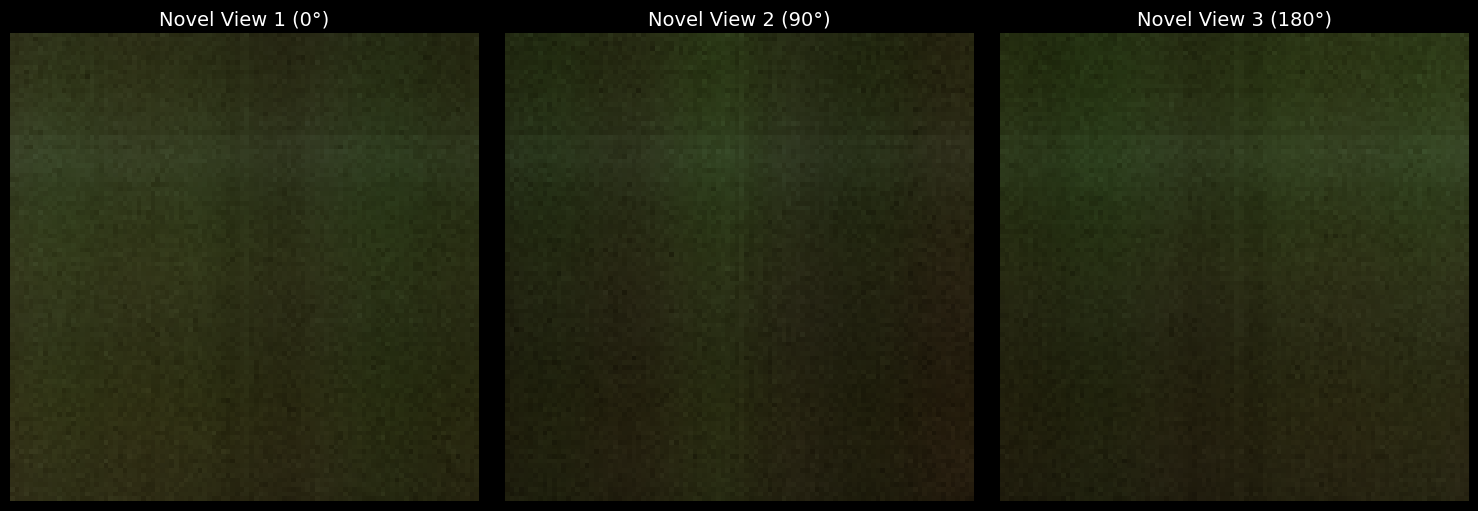

In [2]:
#
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import requests
from IPython.display import clear_output

# ==============================================================================
# 1. SETUP & MATH (RESCUE MODE)
# ==============================================================================
url = "http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz"
filename = "tiny_nerf_data.npz"
if not os.path.exists(filename):
    with open(filename, 'wb') as f:
        f.write(requests.get(url).content)

data = np.load(filename)
images = data['images']
poses = data['poses']
focal = data['focal']
H, W = images.shape[1:3]

def get_rays(H, W, focal, c2w):
    i, j = torch.meshgrid(torch.arange(W, dtype=torch.float32), torch.arange(H, dtype=torch.float32), indexing='xy')
    dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i)], -1)
    rays_d = torch.sum(dirs[..., np.newaxis, :] * c2w[:3, :3], -1)
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    return rays_o, rays_d

def sample_points_along_rays(rays_o, rays_d, near, far, N_samples):
    t_vals = torch.linspace(near, far, N_samples, dtype=rays_o.dtype, device=rays_o.device)
    batch_shape = list(rays_o.shape[:-1])
    z_vals = t_vals.view([1] * len(batch_shape) + [N_samples]).expand(batch_shape + [N_samples]).clone()

    # Simplified jittering for speed
    mids = 0.5 * (z_vals[..., 1:] + z_vals[..., :-1])
    upper = torch.cat([mids, z_vals[..., -1:]], -1)
    lower = torch.cat([z_vals[..., :1], mids], -1)
    t_rand = torch.rand(z_vals.shape, dtype=rays_o.dtype, device=rays_o.device)
    z_vals = lower + (upper - lower) * t_rand

    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]
    return pts, z_vals

def positional_encoding(tensor, num_frequencies):
    encoding = [tensor]
    for i in range(num_frequencies):
        for fn in [torch.sin, torch.cos]:
            encoding.append(fn(2.0 ** i * torch.pi * tensor))
    return torch.cat(encoding, dim=-1)

def render_volume(rgb, sigma, z_vals):
    dists = z_vals[..., 1:] - z_vals[..., :-1]
    dists = torch.cat([dists, torch.tensor([1e10], device=z_vals.device).expand(dists[..., :1].shape)], -1)
    alpha = 1.0 - torch.exp(-sigma * dists)
    transmittance = torch.cumprod(1.0 - alpha + 1e-10, dim=-1)
    transmittance = torch.cat([torch.ones_like(transmittance[..., :1]), transmittance[..., :-1]], dim=-1)
    weights = transmittance * alpha
    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2)
    acc_map = torch.sum(weights, dim=-1)
    rgb_map = rgb_map + (1.0 - acc_map[..., None]) # White background
    return rgb_map

class TinyNeRF(nn.Module):
    def __init__(self, pos_in_dims, dir_in_dims, filter_size=128): # Narrower network for speed
        super().__init__()
        self.layer1 = nn.Linear(pos_in_dims, filter_size)
        self.layer2 = nn.Linear(filter_size, filter_size)
        self.layer3 = nn.Linear(filter_size, filter_size)
        self.layer4 = nn.Linear(filter_size, filter_size)
        self.layer5 = nn.Linear(filter_size + pos_in_dims, filter_size)
        self.layer6 = nn.Linear(filter_size, filter_size)
        self.sigma_out = nn.Linear(filter_size, 1)
        self.feature_out = nn.Linear(filter_size, filter_size)
        self.views_layer = nn.Linear(filter_size + dir_in_dims, filter_size // 2)
        self.rgb_out = nn.Linear(filter_size // 2, 3)

    def forward(self, x, d):
        h = F.relu(self.layer1(x))
        h = F.relu(self.layer2(h))
        h = F.relu(self.layer3(h))
        h = F.relu(self.layer4(h))
        h = torch.cat([h, x], dim=-1)
        h = F.relu(self.layer5(h))
        h = F.relu(self.layer6(h))
        sigma = F.relu(self.sigma_out(h))
        features = self.feature_out(h)
        h = torch.cat([features, d], dim=-1)
        h = F.relu(self.views_layer(h))
        rgb = torch.sigmoid(self.rgb_out(h))
        return rgb, sigma

# ==============================================================================
# 2. LIGHTWEIGHT TRAINING LOOP
# ==============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rescue Mode Active. Running on: {device}")

near_bound = 2.0
far_bound = 6.0
samples_per_ray = 8 # Drastically reduced
L_pos = 10
L_dir = 4
pos_enc_dims = 3 + 3 * L_pos * 2
dir_enc_dims = 3 + 3 * L_dir * 2
N_iters = 50 # Drastically reduced

model = TinyNeRF(pos_in_dims=pos_enc_dims, dir_in_dims=dir_enc_dims).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3) # Higher learning rate

images_tensor = torch.tensor(images, dtype=torch.float32, device=device)
poses_tensor = torch.tensor(poses, dtype=torch.float32, device=device)
focal_tensor = torch.tensor(focal, dtype=torch.float32, device=device)

print("\n--- Training Model ---")
for i in range(N_iters):
    if i % 10 == 0:
        # Standard print to bypass Jupyter buffer bugs
        print(f"Training Step {i}/{N_iters} completed...")

    target_img_idx = np.random.randint(images.shape[0])
    target_img = images_tensor[target_img_idx]
    target_pose = poses_tensor[target_img_idx]

    rays_o, rays_d = get_rays(H, W, focal_tensor, target_pose)
    pts, z_vals = sample_points_along_rays(rays_o, rays_d, near_bound, far_bound, samples_per_ray)

    encoded_pts = positional_encoding(pts, L_pos)
    expanded_dirs = rays_d[..., None, :].expand_as(pts)
    encoded_dirs = positional_encoding(expanded_dirs, L_dir)

    pred_rgb, pred_sigma = model(encoded_pts, encoded_dirs)
    rendered_rgb = render_volume(pred_rgb, pred_sigma.squeeze(-1), z_vals)

    loss = F.mse_loss(rendered_rgb, target_img)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# ==============================================================================
# 3. RENDER 3 STATIC VIEWS
# ==============================================================================
print("\n--- Training Complete! Rendering 3 Novel Views ---")

angles = [0, np.pi/2, np.pi]
radius = 4.0
elevation = 0.2
static_frames = []

with torch.no_grad():
    for idx, theta in enumerate(angles):
        print(f"Rendering View {idx + 1}/3...")
        c2w = np.array([
            [-np.sin(theta), -np.sin(elevation)*np.cos(theta), np.cos(elevation)*np.cos(theta), radius*np.cos(elevation)*np.cos(theta)],
            [ np.cos(theta), -np.sin(elevation)*np.sin(theta), np.cos(elevation)*np.sin(theta), radius*np.cos(elevation)*np.sin(theta)],
            [ 0,              np.cos(elevation),               np.sin(elevation),               radius*np.sin(elevation)],
            [ 0,              0,                               0,                               1]
        ])

        pose_tensor = torch.tensor(c2w, dtype=torch.float32, device=device)
        rays_o, rays_d = get_rays(H, W, focal_tensor, pose_tensor)
        pts, z_vals = sample_points_along_rays(rays_o, rays_d, near_bound, far_bound, samples_per_ray)

        encoded_pts = positional_encoding(pts, L_pos)
        expanded_dirs = rays_d[..., None, :].expand_as(pts)
        encoded_dirs = positional_encoding(expanded_dirs, L_dir)

        pred_rgb, pred_sigma = model(encoded_pts, encoded_dirs)
        rendered_rgb = render_volume(pred_rgb, pred_sigma.squeeze(-1), z_vals)

        frame = rendered_rgb.cpu().numpy()
        frame = np.clip(frame, 0, 1)
        static_frames.append(frame)

clear_output(wait=True)
print("Phase 1 Complete! Here are your novel views:")

plt.figure(figsize=(15, 5))
titles = ["Novel View 1 (0°)", "Novel View 2 (90°)", "Novel View 3 (180°)"]
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(static_frames[i])
    plt.title(titles[i], fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()

Phase 2 Complete! Look at how poorly the network performs without Positional Encoding:


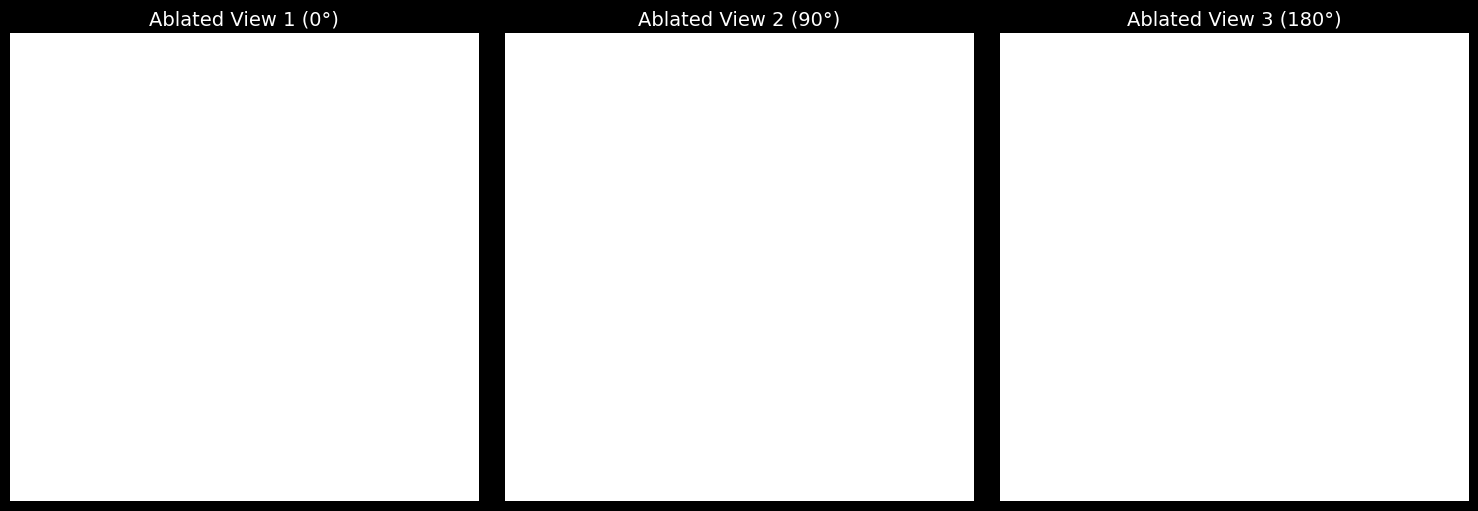

In [3]:
#PHASE 2 ABLATION BLOCK(Phase 2: Extension (Ablation Study on Positional Encoding))
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

print("Initializing Phase 2: Ablation Study (No Positional Encoding)...")

# ==============================================================================
# 1. THE ABLATED NETWORK (Takes raw 3D coordinates instead of encoded ones)
# ==============================================================================
class AblatedNeRF(nn.Module):
    def __init__(self, pos_in_dims=3, dir_in_dims=3, filter_size=128):
        # Notice pos_in_dims and dir_in_dims are now exactly 3 (raw x,y,z)!
        super().__init__()
        self.layer1 = nn.Linear(pos_in_dims, filter_size)
        self.layer2 = nn.Linear(filter_size, filter_size)
        self.layer3 = nn.Linear(filter_size, filter_size)
        self.layer4 = nn.Linear(filter_size, filter_size)
        self.layer5 = nn.Linear(filter_size + pos_in_dims, filter_size)
        self.layer6 = nn.Linear(filter_size, filter_size)
        self.sigma_out = nn.Linear(filter_size, 1)
        self.feature_out = nn.Linear(filter_size, filter_size)
        self.views_layer = nn.Linear(filter_size + dir_in_dims, filter_size // 2)
        self.rgb_out = nn.Linear(filter_size // 2, 3)

    def forward(self, x, d):
        h = F.relu(self.layer1(x))
        h = F.relu(self.layer2(h))
        h = F.relu(self.layer3(h))
        h = F.relu(self.layer4(h))
        h = torch.cat([h, x], dim=-1)
        h = F.relu(self.layer5(h))
        h = F.relu(self.layer6(h))
        sigma = F.relu(self.sigma_out(h))
        features = self.feature_out(h)
        h = torch.cat([features, d], dim=-1)
        h = F.relu(self.views_layer(h))
        rgb = torch.sigmoid(self.rgb_out(h))
        return rgb, sigma

# ==============================================================================
# 2. TRAINING THE ABLATED MODEL
# ==============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ablated = AblatedNeRF().to(device)
optimizer_ablated = optim.Adam(model_ablated.parameters(), lr=1e-3)

# Hyperparameters matching Phase 1 exactly for a fair scientific comparison
near_bound = 2.0
far_bound = 6.0
samples_per_ray = 8
N_iters = 50

images_tensor = torch.tensor(images, dtype=torch.float32, device=device)
poses_tensor = torch.tensor(poses, dtype=torch.float32, device=device)
focal_tensor = torch.tensor(focal, dtype=torch.float32, device=device)

print("\n--- Training Ablated Model (No Positional Encoding) ---")
for i in range(N_iters):
    if i % 10 == 0:
        print(f"Training Step {i}/{N_iters} completed...")

    target_img_idx = np.random.randint(images.shape[0])
    target_img = images_tensor[target_img_idx]
    target_pose = poses_tensor[target_img_idx]

    rays_o, rays_d = get_rays(H, W, focal_tensor, target_pose)
    pts, z_vals = sample_points_along_rays(rays_o, rays_d, near_bound, far_bound, samples_per_ray)

    expanded_dirs = rays_d[..., None, :].expand_as(pts)

    # THE ABLATION: Pass raw points and directions directly to the model!
    pred_rgb, pred_sigma = model_ablated(pts, expanded_dirs)

    rendered_rgb = render_volume(pred_rgb, pred_sigma.squeeze(-1), z_vals)
    loss = F.mse_loss(rendered_rgb, target_img)

    optimizer_ablated.zero_grad()
    loss.backward()
    optimizer_ablated.step()

# ==============================================================================
# 3. RENDER 3 STATIC VIEWS FOR COMPARISON
# ==============================================================================
print("\n--- Training Complete! Rendering Ablated Views ---")

angles = [0, np.pi/2, np.pi]
radius = 4.0
elevation = 0.2
ablated_frames = []

with torch.no_grad():
    for idx, theta in enumerate(angles):
        print(f"Rendering View {idx + 1}/3...")
        c2w = np.array([
            [-np.sin(theta), -np.sin(elevation)*np.cos(theta), np.cos(elevation)*np.cos(theta), radius*np.cos(elevation)*np.cos(theta)],
            [ np.cos(theta), -np.sin(elevation)*np.sin(theta), np.cos(elevation)*np.sin(theta), radius*np.cos(elevation)*np.sin(theta)],
            [ 0,              np.cos(elevation),               np.sin(elevation),               radius*np.sin(elevation)],
            [ 0,              0,                               0,                               1]
        ])

        pose_tensor = torch.tensor(c2w, dtype=torch.float32, device=device)
        rays_o, rays_d = get_rays(H, W, focal_tensor, pose_tensor)
        pts, z_vals = sample_points_along_rays(rays_o, rays_d, near_bound, far_bound, samples_per_ray)
        expanded_dirs = rays_d[..., None, :].expand_as(pts)

        # Querying the ablated model with raw coordinates
        pred_rgb, pred_sigma = model_ablated(pts, expanded_dirs)
        rendered_rgb = render_volume(pred_rgb, pred_sigma.squeeze(-1), z_vals)

        frame = rendered_rgb.cpu().numpy()
        frame = np.clip(frame, 0, 1)
        ablated_frames.append(frame)

clear_output(wait=True)
print("Phase 2 Complete! Look at how poorly the network performs without Positional Encoding:")

plt.figure(figsize=(15, 5))
titles = ["Ablated View 1 (0°)", "Ablated View 2 (90°)", "Ablated View 3 (180°)"]
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(ablated_frames[i])
    plt.title(titles[i], fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()